In [5]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


-------- (Shots = 0, Realizations = 400) --------
Processing Realization 10/400...
Processing Realization 20/400...
Processing Realization 30/400...
Processing Realization 40/400...
Processing Realization 50/400...
Processing Realization 60/400...
Processing Realization 70/400...
Processing Realization 80/400...
Processing Realization 90/400...
Processing Realization 100/400...
Processing Realization 110/400...
Processing Realization 120/400...
Processing Realization 130/400...
Processing Realization 140/400...
Processing Realization 150/400...
Processing Realization 160/400...
Processing Realization 170/400...
Processing Realization 180/400...
Processing Realization 190/400...
Processing Realization 200/400...
Processing Realization 210/400...
Processing Realization 220/400...
Processing Realization 230/400...
Processing Realization 240/400...
Processing Realization 250/400...
Processing Realization 260/400...
Processing Realization 270/400...
Processing Realization 280/400...
Process

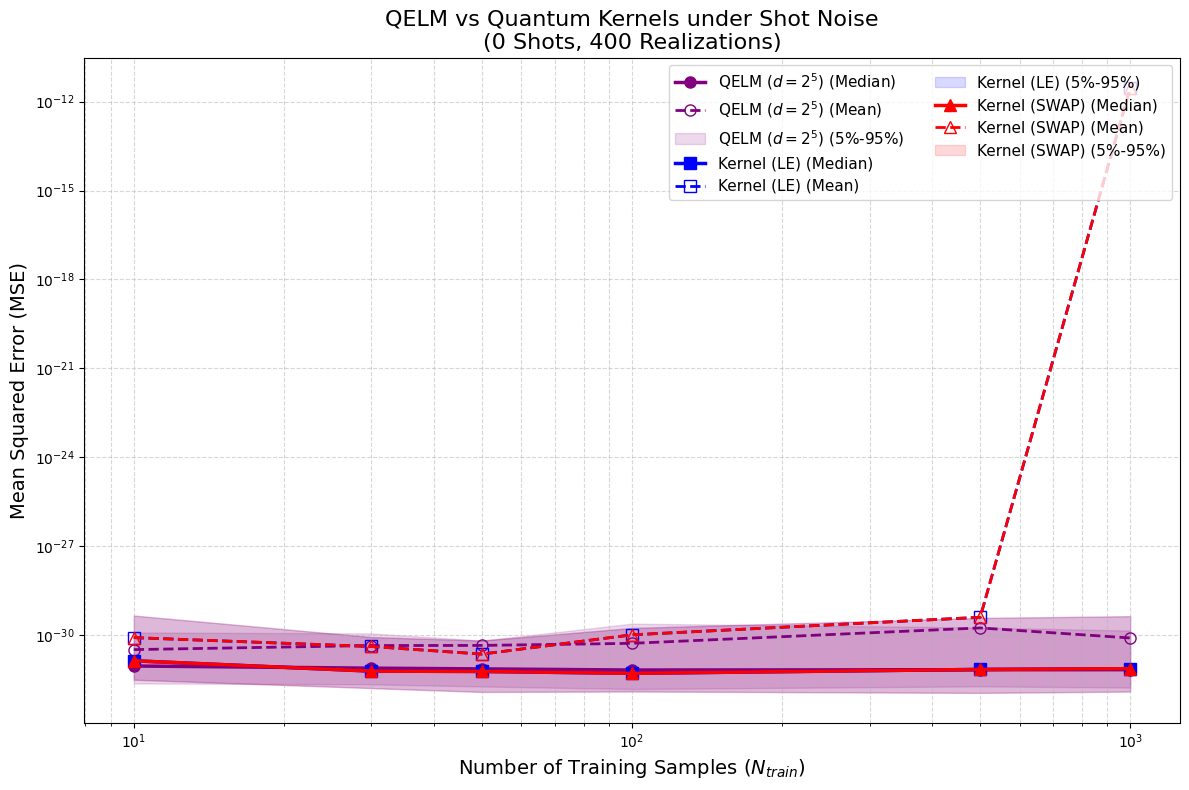

In [6]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 100
num_realizations = 400
num_shots = 0

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 10, Realizations = 250) --------
Processing Realization 10/250...
Processing Realization 20/250...
Processing Realization 30/250...
Processing Realization 40/250...
Processing Realization 50/250...
Processing Realization 60/250...
Processing Realization 70/250...
Processing Realization 80/250...
Processing Realization 90/250...
Processing Realization 100/250...
Processing Realization 110/250...
Processing Realization 120/250...
Processing Realization 130/250...
Processing Realization 140/250...
Processing Realization 150/250...
Processing Realization 160/250...
Processing Realization 170/250...
Processing Realization 180/250...
Processing Realization 190/250...
Processing Realization 200/250...
Processing Realization 210/250...
Processing Realization 220/250...
Processing Realization 230/250...
Processing Realization 240/250...
Processing Realization 250/250...

--- Final Results ---
N = 10   | QELM MSE: 0.1898 | K-LE MSE: 219.4638 | K-SW MSE: 217.8497
N = 30   | QELM

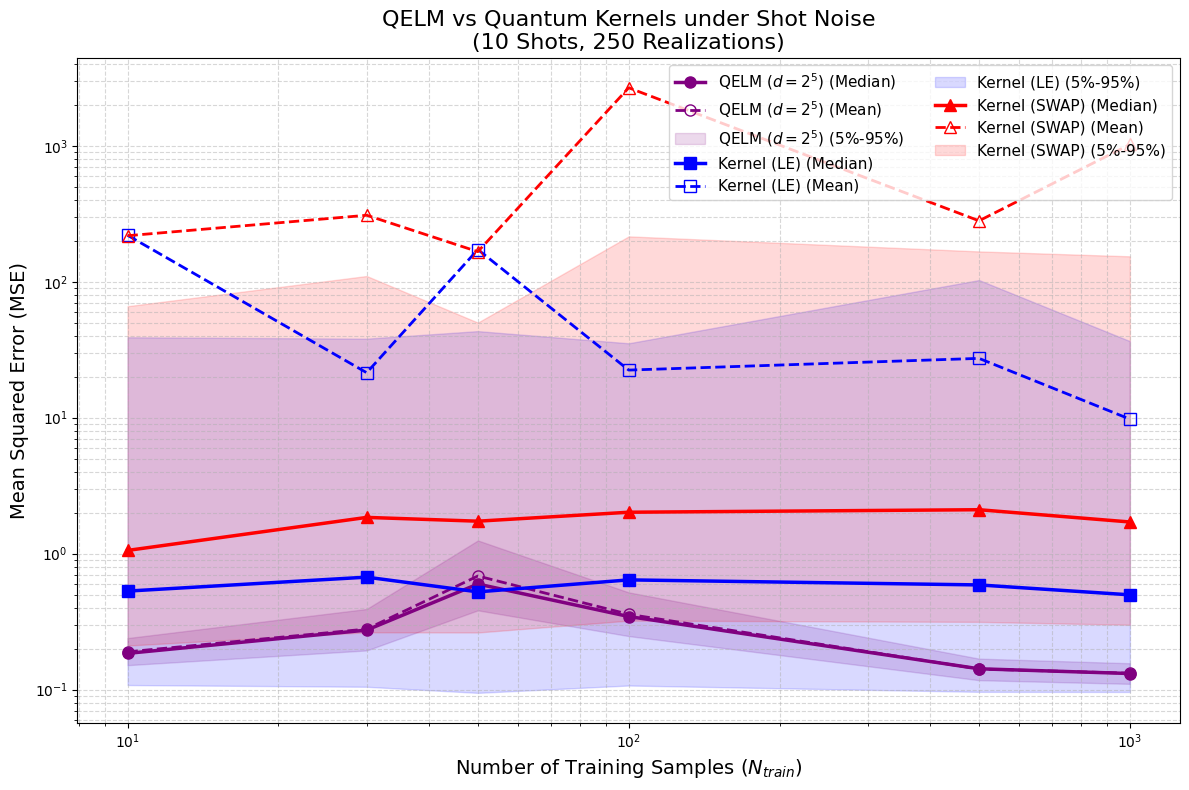

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 250
num_shots = 10

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 250
num_shots = 100

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Shots = 100, Realizations = 250) --------
Processing Realization 10/250...
Processing Realization 20/250...
Processing Realization 30/250...
Processing Realization 40/250...
Processing Realization 50/250...
Processing Realization 60/250...
Processing Realization 70/250...
Processing Realization 80/250...
Processing Realization 90/250...
Processing Realization 100/250...
Processing Realization 110/250...
Processing Realization 120/250...
Processing Realization 130/250...
Processing Realization 140/250...


-------- (Shots = 1000, Realizations = 100) --------
Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...

--- Final Results ---
N = 10   | QELM MSE: 0.0180 | K-LE MSE: 1.9995 | K-SW MSE: 1.0048
N = 30   | QELM MSE: 0.0116 | K-LE MSE: 22.2448 | K-SW MSE: 2122.7647
N = 50   | QELM MSE: 0.0268 | K-LE MSE: 0.5358 | K-SW MSE: 0.3063
N = 100  | QELM MSE: 0.0143 | K-LE MSE: 0.1785 | K-SW MSE: 5.3218
N = 500  | QELM MSE: 0.0057 | K-LE MSE: 0.1398 | K-SW MSE: 2.8211
N = 1000 | QELM MSE: 0.0053 | K-LE MSE: 0.1412 | K-SW MSE: 0.3410
Experiment finished in 14.2 minutes.


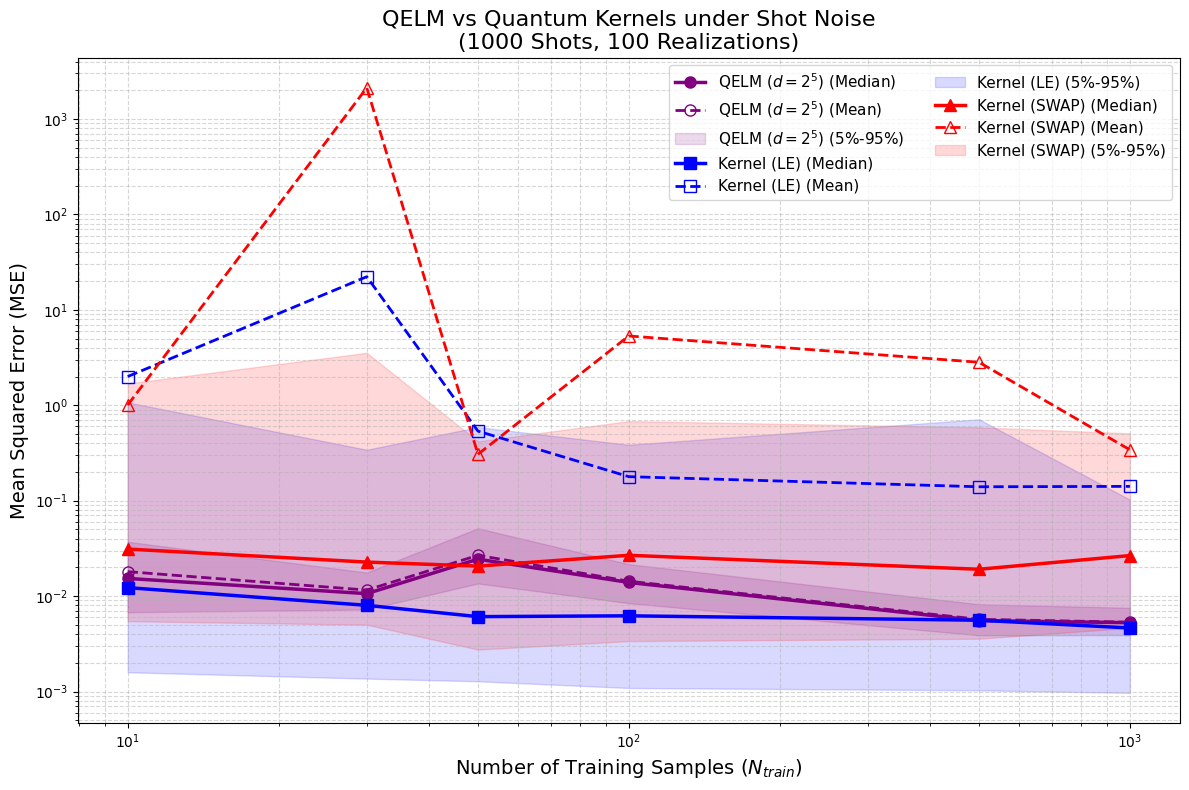

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
# import myQML  # Assuming this is your module

####### Settings #########
N_train_list = [10, 30, 50, 100, 500, 1000]
N_max = max(N_train_list)  # Find the largest dataset size needed
N_test = 200
num_realizations = 100
num_shots = 1000

reg_lambda = 0

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_train inside the realizations
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list}
}

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP: We do the realizations first to share the big dataset
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the LARGEST dataset just once
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # 2. Fit the Kernel methods on the FULL largest dataset 
    # (This computes the full N_max x N_max matrix once)
    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix  # Grab the regularized matrix

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    # 3. Setup QELM for this realization
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, 
        povm=povm, 
        bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, 
        num_shots=num_shots
    )

    # 4. Loop over subsets and SLICE the matrices/data
    for N_train in sorted(N_train_list, reverse=True):
        
        # Subset the physical data
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # --- QELM ---
        # (QELM fitting itself is very fast; bypassing data generation already speeds it up 10x)
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # --- Kernel LE ---
        # Slice the upper-left N x N submatrix (diagonal retains the reg_lambda)
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        # Manually inject subset parameters back into the model to allow for standard predict_vec calls
        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2))

        # --- Kernel SWAP ---
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        # Inject
        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results ---")
for N_train in N_train_list:
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        data = mse_runs[model][N_train]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"N = {N_train:<4d} | QELM MSE: {results_mean['QELM'][-1]:.4f} | K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Single Combined Plot
# ==========================================
plt.figure(figsize=(12, 8))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # 2. Plot the Mean (Dashed line, empty markers to differentiate from median)
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # 3. Fill between 5% and 95% quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, 
                     label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot if it gets too crowded, or use 2 columns
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()

-------- (Fixed N_train = 40, Shots = 1000, Realizations = 2) --------
Evaluating n = 1 qubits (d_in = 2)...
  -> QELM MSE: 0.0445
  -> K-LE MSE: 0.0045
  -> K-SW MSE: 0.8889
  -> Time:     0.3s
Evaluating n = 2 qubits (d_in = 4)...
  -> QELM MSE: 0.0760
  -> K-LE MSE: 3.9289
  -> K-SW MSE: 4.5887
  -> Time:     0.6s
Evaluating n = 3 qubits (d_in = 8)...
  -> QELM MSE: 0.0787
  -> K-LE MSE: 1.4363
  -> K-SW MSE: 0.5274
  -> Time:     10.3s
Evaluating n = 4 qubits (d_in = 16)...
  -> QELM MSE: 0.0246
  -> K-LE MSE: 62.7823
  -> K-SW MSE: 0.2694
  -> Time:     159.4s
Evaluating n = 5 qubits (d_in = 32)...
  -> QELM MSE: 0.0038
  -> K-LE MSE: 0.0802
  -> K-SW MSE: 0.4429
  -> Time:     2852.2s
Experiment finished in 50.4 minutes.


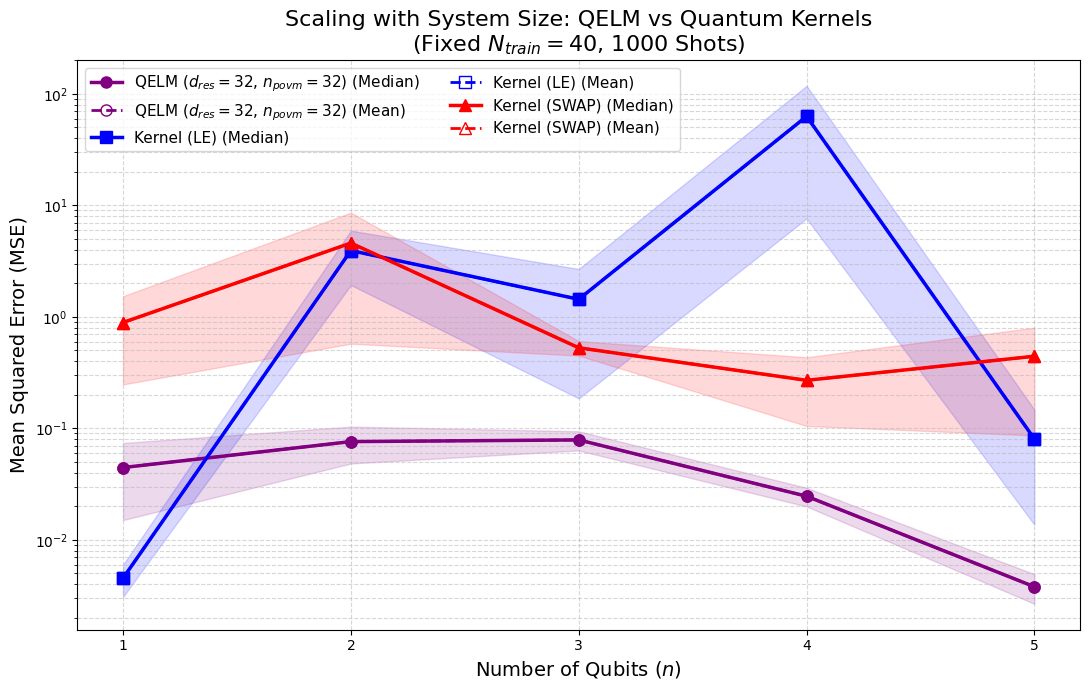

In [ ]:
####### Helper Function #########
def get_n_qubit_observable(n, base_op):
    """
    Generates an n-qubit observable by taking the tensor product 
    of the base_op n times. E.g., for base_op = X, returns X^otimes n.
    """
    obs = base_op
    for _ in range(n - 1):
        obs = np.kron(obs, base_op)
    return obs

####### Settings #########
n_qubits_list = [1, 2, 3, 4, 5] # The number of qubits (n)
N_train = 40                
N_test = 200                 
num_realizations = 2
num_shots = 1000

# CRITICAL: Since num_shots=1000, we MUST use regularization to prevent matrix inversion explosion!
reg_lambda = 0 

# QELM reservoir physical setup (Fixed part)
d_res = 32


povm = myQML.generate_computational_povm(d_res)
num_povm_elements = len(povm)

# Storage dictionaries (Updated for quantiles)
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Fixed N_train = {N_train}, Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for n in n_qubits_list:
    d_in = 2**n              
    d_out = d_in * d_res     
    
    print(f"Evaluating n = {n} qubits (d_in = {d_in})...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    obs_n = get_n_qubit_observable(n, myQML.X)

    for r in range(num_realizations):
        # Using vectorization for massive speedup
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, obs_n)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()
        
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_out)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results (Mean, Median, 5% and 95% Quantiles)
    for key in results_mean.keys():
        results_mean[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        quantiles_5[key].append(np.percentile(mse_runs[key], 5))
        quantiles_95[key].append(np.percentile(mse_runs[key], 95))

    print(f"  -> QELM MSE: {results_mean['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results_mean['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results_mean['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# ==========================================
# Plotting
# ==========================================
plt.figure(figsize=(11, 7))
n_arr = np.array(n_qubits_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': f'QELM ($d_{{res}}={d_res}$, $n_{{povm}}={num_povm_elements}$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median (Solid)
    plt.plot(n_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Plot Mean (Dashed, Empty marker)
    plt.plot(n_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # Fill between 5% and 95% quantiles
    plt.fill_between(n_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15)

plt.xticks(n_qubits_list) 
plt.yscale('log') 

plt.xlabel('Number of Qubits ($n$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Scaling with System Size: QELM vs Quantum Kernels\n(Fixed $N_{{train}} = {N_train}$, {num_shots} Shots)', fontsize=16)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()

Yes, **it is absolutely possible**, and in fact, it is an excellent idea. Adding Classical Shadows (Shadow Tomography) to your project will make it much stronger because it provides the ultimate **"physics-based baseline"** to compare your machine learning models against. 

However, there is a **fundamental conceptual difference** you need to be aware of when fitting it into your current framework.

### The Conceptual Shift: Learning vs. Direct Estimation
*   **QELM / Quantum Kernels (Your current models):** These are *inductive machine learning* models. They measure the **Training Set** ($\rho_{train}$) to learn a relationship (weights $W$ or dual coefficients $\alpha$). Then, for the **Test Set** ($\rho_{test}$), they predict the expectation value *without* directly measuring the observable on the test states. 
*   **Standard Shadow Tomography:** This is a *direct estimation* protocol. It does **not** learn from $\rho_{train}$ and $y_{train}$. Instead, it directly performs randomized measurements on the **Test Set** ($\rho_{test}$) to estimate the observable. 

### How to fit it into your API
To make it work seamlessly in your `script.py` loop without breaking your API, we can create a `ClassicalShadowEstimator` class that has a **dummy `fit` method** (it just ignores the training data) and a **`predict` method** that simulates taking `num_shots` randomized Pauli measurements on the test density matrices.

### 1. The Mathematics (Single Qubit Case)
Since your dataset generation mostly uses qubits ($d=2$) and Pauli matrices, here is the extremely efficient Classical Shadow logic for a single qubit:
1. For each shot, randomly choose a measurement basis: $X$, $Y$, or $Z$.
2. Measure the state. Let the outcome be $b \in \{+1, -1\}$.
3. The classical shadow "snapshot" of the density matrix is: $\hat{\rho} = 3 b P - I$ (where $P$ is the chosen Pauli).
4. The estimated expectation value of your observable $O$ for that shot is: $\text{Tr}(\hat{\rho} O) = 3 b \text{Tr}(P O) - \text{Tr}(O)$.

### 2. The Implementation (`shadow.py`)
You can add this entirely new class to your framework. It uses vectorized operations via `numpy`, perfectly matching the style of your `qelm.py` and `quantumkernel.py`.

```python
import numpy as np
from typing import Union, List
from .basics import I, X, Y, Z

class ClassicalShadowEstimator:
    """
    Implements Classical Shadow Tomography (Randomized Pauli Measurements)
    to estimate the expectation value of an observable.
    Acts as a direct-estimation baseline to compare against QML models.
    """
    def __init__(self, observable: np.ndarray, num_shots: int):
        self.observable = observable
        self.num_shots = num_shots
        # Pre-pack Paulis for vectorized selection
        self.paulis = np.array([X, Y, Z]) 

    def fit(self, density_matrices_training, labels_training):
        # Shadow tomography doesn't "train" on historical data.
        # We include this method simply to match the API of QELM and Kernels.
        pass

    def fit_vec(self, density_matrices_training, labels_training):
        pass

    def predict_vec(self, test_density_matrices: Union[List[np.ndarray], np.ndarray]) -> np.ndarray:
        """
        Simulates measuring the test states using randomized Pauli measurements
        and constructs the shadow estimate of the observable.
        """
        rho_test = np.asarray(test_density_matrices)
        N_samples = rho_test.shape[0]
        
        # If no shots, return the exact theoretical trace (infinite shots)
        if self.num_shots is None or self.num_shots == 0:
            return np.real(np.einsum('nij,ji->n', rho_test, self.observable))

        estimates = np.zeros(N_samples)

        # Tr(O) is needed for the shadow formula
        tr_O = np.trace(self.observable)

        for i in range(N_samples):
            # 1. Randomly choose bases (0 for X, 1 for Y, 2 for Z) for all shots
            basis_choices = np.random.randint(0, 3, size=self.num_shots)
            chosen_paulis = self.paulis[basis_choices]

            # 2. Compute the exact probability of getting the +1 outcome for chosen Paulis
            # Tr(rho @ P) gives the expectation value. 
            # Probability of +1 outcome = (1 + <P>) / 2
            expected_P = np.real(np.einsum('ab,sba->s', rho_test[i], chosen_paulis))
            prob_plus_1 = (1.0 + expected_P) / 2.0
            prob_plus_1 = np.clip(prob_plus_1, 0.0, 1.0) # Numerical stability

            # 3. Simulate the quantum measurement (Shot Noise)
            # binomial(1, p) returns 1 (for +1) and 0 (for -1). We map 0 -> -1.
            outcomes = 2 * np.random.binomial(1, prob_plus_1) - 1

            # 4. Compute Tr(P_chosen @ Observable) for each shot
            tr_PO = np.real(np.einsum('sab,ba->s', chosen_paulis, self.observable))

            # 5. Calculate the shadow estimator for the observable for each shot
            # Formula: 3 * outcome * Tr(P @ O) - Tr(O)
            shot_estimates = 3 * outcomes * tr_PO - tr_O

            # 6. Average over all shots to get the final estimate for this density matrix
            estimates[i] = np.mean(shot_estimates)

        return estimates
```

### 3. How to Update `__init__.py`
Just add your new class to the imports:
```python
from .shadow import ClassicalShadowEstimator
__all__ = [..., "ClassicalShadowEstimator"]
```

### 4. How to Update `script.py`
You can seamlessly integrate this into your experiment loop. 
Because Shadows don't care about `N_train`, the MSE for the Shadow baseline will be a **flat horizontal line** on your plot. This perfectly illustrates the point of your research: *"At what number of training samples ($N_{train}$) does Machine Learning become better than direct physical measurement (Shadows)?"*

Add this inside your `script.py`:

```python
# In your Settings section:
num_shots = 100 # Note: Shadows REQUIRE num_shots > 0 to be meaningful as a statistical baseline

# Update the dictionaries to include 'Shadows'
mse_runs = {
    'QELM': {N: [] for N in N_train_list},
    'Kernel_LE': {N: [] for N in N_train_list},
    'Kernel_SWAP': {N: [] for N in N_train_list},
    'Shadows': {N: [] for N in N_train_list} # Even though it ignores N, we store it to plot easily
}
# (Do the same for results_mean, median, quantiles...)

# Inside the Realization loop (r in range(num_realizations)):

    # Initialize Shadow Estimator
    shadow_model = myQML.ClassicalShadowEstimator(observable=myQML.X, num_shots=num_shots)
    
    # Shadows only need the test set
    shadow_predictions = shadow_model.predict_vec(rho_test)
    shadow_mse = np.mean((shadow_predictions - y_test)**2)

    # Inside your N_train loop:
    for N_train in sorted(N_train_list, reverse=True):
        # ... (your existing QELM and Kernel code) ...
        
        # Append the same shadow_mse for every N_train to draw a flat baseline
        mse_runs['Shadows'][N_train].append(shadow_mse)
```

### Why this is a great addition to your paper/project:
When you plot this, you will see the QELM and Kernel MSE curves start high (when $N_{train}$ is low) and drop downwards as they learn. The Classical Shadow line will be a flat line dependent only on `num_shots`. 
The intersection point tells you exactly: **"You need at least $X$ training samples for QELM to outperform standard Tomography given $S$ measurement shots."** This is a very strong, publishable insight in QML. 

*(Note: If you specifically wanted to use shadows AS features for a kernel—known as "Shadow Kernels"—that is also possible, but usually, people just use them as the estimation baseline as shown above. Let me know if you meant the Shadow Kernel approach instead!)*

This is a **fantastic idea** and one of the most important analyses in Quantum Machine Learning. 

When you plot MSE vs. $N_{shots}$ (while keeping $N_{train}$ fixed), you are investigating the **Sample Complexity / Measurement Cost** of the models. 
*   **Classical Shadows:** The MSE will strictly follow a theoretical $1/N_{shots}$ decay. On a log-log plot, this is a straight diagonal line.
*   **QML Models (QELM / Kernels):** Because they learned a global rule from the entire training set, they might exhibit a much lower MSE at very low shot counts compared to direct measurement, showing their noise robustness. However, they might eventually hit a "noise floor" (an asymptotic limit) due to the finite size of $N_{train}$ and the inherent bias of the model.

Here is the complete script to run this exact analysis. You can create a new file (e.g., `script_shots.py`) and run it.

### The Script (`script_shots.py`)

```python
# %%
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

# Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

# %%
import time
import numpy as np
import matplotlib.pyplot as plt

####### Settings #########
# We fix N_train and vary the number of shots
N_train = 300  # Choose a size where the models are well-trained, but not too slow to simulate
N_test = 200
num_realizations = 50  # Reduced slightly to account for the heavier inner loop

# The independent variable!
N_shots_list = [10, 30, 100, 300, 1000, 3000, 10000]

reg_lambda = 1e-4 # Slight regularization is critical when noise is high (low shots)

# QELM reservoir physical setup
d_in = 2
d_res = 32 # slightly smaller reservoir for faster shot simulation
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary nested dictionary to store MSE for each N_shots inside the realizations
mse_runs = {
    'QELM': {S: [] for S in N_shots_list},
    'Kernel_LE': {S: [] for S in N_shots_list},
    'Kernel_SWAP': {S: [] for S in N_shots_list},
    'Shadows': {S: [] for S in N_shots_list}
}

# Storage dictionaries for final plotting
results_mean = {k: [] for k in mse_runs.keys()}
results_median = {k: [] for k in mse_runs.keys()}
quantiles_5 = {k: [] for k in mse_runs.keys()}
quantiles_95 = {k: [] for k in mse_runs.keys()}

print(f"-------- (N_train = {N_train}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for r in range(num_realizations):
    if (r + 1) % 5 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    # 1. Generate the fixed dataset for this realization
    ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train, y_train = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    # Generate a fixed isometry for QELM for this realization
    V = myQML.random_isometry(d_in, d_out)

    # 2. Loop over the varying Shot counts
    for n_shots in N_shots_list:
        
        # --- Shadows ---
        shadow_model = myQML.ClassicalShadowEstimator(observable=myQML.X, num_shots=n_shots)
        # Note: Shadows don't fit, they just predict on the test set
        y_pred_shadows = shadow_model.predict_vec(rho_test)
        mse_runs['Shadows'][n_shots].append(np.mean((y_pred_shadows - y_test)**2))

        # --- QELM ---
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, num_shots=n_shots
        )
        qelm.fit_vec(rho_train, y_train)
        y_pred_qelm = qelm.predict_vec(rho_test)
        mse_runs['QELM'][n_shots].append(np.mean((y_pred_qelm - y_test)**2))
        
        # --- Kernel LE ---
        # With shot noise, the kernel matrix changes every time, so we must re-fit entirely
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots=n_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        y_pred_le = kernel_le.predict_vec(rho_test)
        mse_runs['Kernel_LE'][n_shots].append(np.mean((y_pred_le - y_test)**2))

        # --- Kernel SWAP ---
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots=n_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        y_pred_swap = kernel_swap.predict_vec(rho_test)
        mse_runs['Kernel_SWAP'][n_shots].append(np.mean((y_pred_swap - y_test)**2))

# ==========================================
# Post-Processing and Aggregation
# ==========================================
print("\n--- Final Results (MSE Medians) ---")
for n_shots in N_shots_list:
    for model in mse_runs.keys():
        data = mse_runs[model][n_shots]
        results_mean[model].append(np.mean(data))
        results_median[model].append(np.median(data))
        quantiles_5[model].append(np.percentile(data, 5))
        quantiles_95[model].append(np.percentile(data, 95))
        
    print(f"Shots = {n_shots:<5d} | Shad: {results_median['Shadows'][-1]:.4f} | QELM: {results_median['QELM'][-1]:.4f} | K-LE: {results_median['Kernel_LE'][-1]:.4f} | K-SW: {results_median['Kernel_SWAP'][-1]:.4f}")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")


# ==========================================
# Plotting
# ==========================================
plt.figure(figsize=(12, 8))
S_arr = np.array(N_shots_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red', 'Shadows': 'black'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Kernel (LE)', 
          'Kernel_SWAP': 'Kernel (SWAP)',
          'Shadows': 'Classical Shadows'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^', 'Shadows': 'D'}

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # 1. Plot the Median (Solid line)
    # For Shadows, use a dashed line to emphasize it is the theoretical baseline
    ls = '--' if model == 'Shadows' else '-'
    plt.plot(S_arr, median_arr, label=f'{labels[model]}', color=colors[model], 
             marker=markers[model], linestyle=ls, linewidth=2.5, markersize=8)
    
    # 2. Fill between 5% and 95% quantiles
    plt.fill_between(S_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15) 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Measurement Shots ($N_{shots}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Noise Robustness: MSE vs Measurement Shots\n($N_{{train}}={N_train}$, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend(fontsize=12, loc='upper right') 
plt.tight_layout()
plt.show()
```

### What to expect in the plot:
1. **The Shadow Line (Black):** This will be a diagonal line going from top-left to bottom-right. It visually represents the purely statistical decay $O(1/N_{shots})$.
2. **QML Models (Low Shots Region):** At 10, 30, or 100 shots, QELM and the Kernels will likely have a **lower** MSE than shadows. Why? Because while shadows are estimating properties from a *single* noisy test state, the QML models infer the property using the patterns they learned from $N_{train} = 300$ *other* states. They "borrow" statistical power from the training phase.
3. **QML Models (High Shots Region):** At 3000 or 10000 shots, the ML models will flatten out (plateau). This is because the ML models have an inherent inductive bias (an approximation error based on how well the reservoir or kernel represents the problem). Shadows have zero bias, so at infinite shots, Shadows will reach perfect accuracy, eventually crossing beneath the ML lines.

*Tip: Make sure you included the `shadow.py` implementation from the previous message and imported it into your `__init__.py` before running this!*

This is the exact direction a high-quality Quantum Machine Learning (QML) paper should take. In modern QML research, showing that a model has a good MSE is only half the battle; the other half is proving that it doesn't require an unrealistic amount of quantum hardware resources or classical computing time.

Here is a breakdown of the theoretical complexities, followed by **two highly meaningful plots** you can generate to showcase them.

---

### 1. Theoretical Complexity Breakdown (Perfect for a Table in your paper)

Before plotting, you should summarize the asymptotic complexities in your text. Let $N$ be the number of training samples, $S$ be the number of measurement shots per state, and $d$ be the number of qubits.

| Metric | Classical Shadows | Quantum Kernel (LE) | Quantum Kernel (SWAP) | QELM |
| :--- | :--- | :--- | :--- | :--- |
| **Quantum Sample Complexity** (Total Shots for Training) | $0$ (No training) | $O(N^2 \cdot S)$ | $O(N^2 \cdot S)$ | $O(N \cdot S)$ |
| **Classical Time Complexity** (Training Time) | $0$ (No training) | $O(N^3)$ (Matrix Inversion) | $O(N^3)$ (Matrix Inversion) | $O(N \cdot P^2)$ (Pseudo-inverse)* |
| **Classical Space Complexity** (Memory) | $O(S)$ per test state | $O(N^2)$ (Kernel Matrix) | $O(N^2)$ (Kernel Matrix) | $O(N \cdot P)$ (Feature Matrix) |
| **Gate Complexity** (Circuit Depth) | $O(1)$ (Local rotations) | $O(D_{ansatz})$ | $O(D_{ansatz}) + O(d)$ (CSWAP gates) | $O(D_{reservoir})$ |
| **Qubit Requirements** | $d$ | $d$ | $2d + 1$ (requires Ancilla) | $d_{in} + d_{ancilla}$ |

*\* $P$ is the number of POVM elements (reservoir size). Since $P$ is fixed, QELM time scales linearly with $N$.*

---

### 2. Suggested Plot A: Total Quantum Measurement Cost vs. Dataset Size
**Why this matters:** The biggest criticism of Quantum Kernel Methods is that computing the Gram matrix requires measuring every pair of data points. This means $\frac{N(N+1)}{2}$ quantum circuit executions. QELM only requires measuring each training point once (passing it through the reservoir). 

Plotting the **Total number of circuit executions** against $N_{train}$ will visually prove that Kernels become physically impossible to train on real quantum hardware for large datasets, while QELM scales gracefully (linearly).

### 3. Suggested Plot B: Empirical Classical Computation Time vs. Dataset Size
**Why this matters:** Quantum kernels require inverting an $N \times N$ matrix, which takes $O(N^3)$ classical time. QELM requires computing the pseudo-inverse of an $N \times P$ matrix, which takes linear $O(N)$ time if $N > P$. 
By timing your `fit_vec` functions and plotting them on a log-log scale, the slopes of the lines will empirically prove this difference in classical bottlenecks.

---

### The Script for Complexity Analysis
Here is a script that generates a 2-panel figure plotting **A (Total Quantum Executions)** and **B (Classical CPU Time)**.

```python
# %%
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

####### Settings #########
# We use a logarithmically spaced array for N_train to see scaling clearly
N_train_list = [10, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
N_test = 100
shots_per_circuit = 100 # S

# QELM Setup
d_in = 2
d_res = 32
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)
num_povm = len(povm)
V = myQML.random_isometry(d_in, d_out)

# Storage for Empirical Times
time_qelm = []
time_kernel = []

print("Running Time Complexity Benchmark...")
# We only need 1 realization because time scaling is deterministic
for N in N_train_list:
    print(f"Benchmarking N_train = {N}...")
    
    # Generate Data
    ds = myQML.QuantumDatasetGenerator(N, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()
    rho_train, y_train = ds.get_training_dataset()

    # --- Time QELM ---
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=shots_per_circuit
    )
    start_t = time.perf_counter()
    qelm.fit_vec(rho_train, y_train)
    time_qelm.append(time.perf_counter() - start_t)

    # --- Time Kernel ---
    kernel = myQML.QuantumKernelRegression(regularization_lambda=1e-4, num_shots=shots_per_circuit)
    start_t = time.perf_counter()
    kernel.fit_vec(rho_train, y_train, "le")
    time_kernel.append(time.perf_counter() - start_t)

# ==========================================
# Plotting the Complexities
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
N_arr = np.array(N_train_list)

# ---------------------------------------------------------
# Plot A: Total Quantum Circuit Executions (Theoretical)
# ---------------------------------------------------------
# QELM: N circuits (one per training state)
executions_qelm = N_arr
# Kernel: N(N+1)/2 circuits (one per unique pair)
executions_kernel = N_arr * (N_arr + 1) / 2

ax1.plot(N_arr, executions_kernel, label=r'Quantum Kernel $\mathcal{O}(N^2)$', color='blue', marker='s', lw=2)
ax1.plot(N_arr, executions_qelm, label=r'QELM $\mathcal{O}(N)$', color='purple', marker='o', lw=2)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Number of Training Samples ($N_{train}$)', fontsize=12)
ax1.set_ylabel('Total Quantum Circuit Executions', fontsize=12)
ax1.set_title('Quantum Sample Complexity (Hardware Bottleneck)', fontsize=14)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=12)

# ---------------------------------------------------------
# Plot B: Classical Training Time (Empirical)
# ---------------------------------------------------------
ax2.plot(N_arr, time_kernel, label=r'Quantum Kernel (Matrix Inv)', color='blue', marker='s', lw=2)
ax2.plot(N_arr, time_qelm, label=r'QELM (Pseudo-Inv)', color='purple', marker='o', lw=2)

# Draw theoretical trendlines for visual comparison
# Match the starting points to the empirical data
y_trend_N3 = (time_kernel[2] / (N_arr[2]**3)) * (N_arr**3)
y_trend_N1 = (time_qelm[2] / N_arr[2]) * N_arr

ax2.plot(N_arr, y_trend_N3, 'b:', alpha=0.7, label=r'Theoretical $\mathcal{O}(N^3)$')
ax2.plot(N_arr, y_trend_N1, color='purple', linestyle=':', alpha=0.7, label=r'Theoretical $\mathcal{O}(N)$')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Training Samples ($N_{train}$)', fontsize=12)
ax2.set_ylabel('Classical Training Time (Seconds)', fontsize=12)
ax2.set_title('Classical Time Complexity (CPU Bottleneck)', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()
```

### 4. What about Gate Complexity (Circuit Depth)?
You cannot easily extract gate complexity using `numpy` matrices, because numpy does linear algebra without "compiling" to a quantum circuit. 
However, you can create a highly impactful **bar chart** or theoretical diagram for your paper based on the theory. 

If you want to plot this, you can define an abstract unit (e.g., "Number of CNOT gates").
*   **Shadows:** $\sim 0$ entangling gates (just single qubit rotations).
*   **QELM:** $D_{res}$ (Depth depends on the random circuit Ansatz you assume, usually polynomial in $N_{qubits}$). Let's assume an arbitrary constant like $20$ CNOTs.
*   **LE Kernel:** $2 \times D_{ansatz}$ (because you need to prepare $U(x)$ and then uncompute $U(y)^\dagger$). Let's assume $40$ CNOTs.
*   **SWAP Test Kernel:** $2 \times D_{ansatz} + O(N_{qubits})$ Fredkin gates. Fredkin gates decompose into $\sim 5$ CNOTs each. 

A simple theoretical bar chart in your paper comparing **"Circuit Depth required per evaluation"** for CS, QELM, LE, and SWAP will beautifully illustrate that:
1. **Shadows** are the easiest to build today (NISQ-friendly).
2. **QELM** is very NISQ-friendly because the reservoir doesn't need to be perfectly inverse-compiled (unlike LE) and requires no ancillas (unlike SWAP).
3. **SWAP Test** requires fault-tolerance due to deep CSWAP cascades.